**Import Libraries**

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

**The Data**

In [2]:
df=pd.read_csv("Titanic-Dataset.csv")


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Exploratory Data Analysis

Let's begin some exploratory data analysis! We'll start by checking out missing data!

**Missing Values**

We can use seaborn to create a simple heatmap to see where we are missing data!

In [4]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

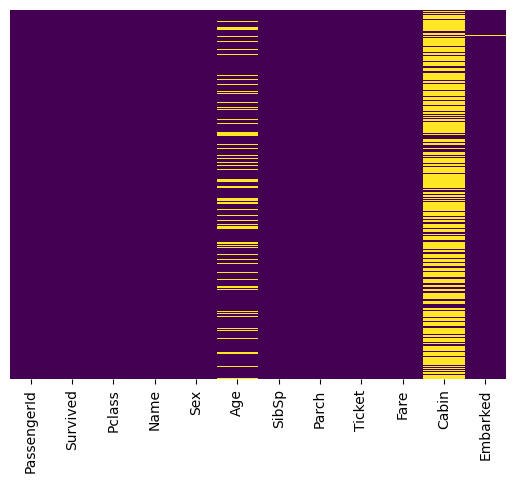

In [5]:
sns.heatmap(df.isnull(), yticklabels=False,cbar=False, cmap='viridis')

### Parameter Breakdown

* **`sns`**: The standard shorthand alias for the Seaborn library.
* **`heatmap`**: A Seaborn function that plots rectangular data as a color-coded matrix.
* **`train.isnull()`**: Creates a boolean mask of the dataset where `True` indicates a missing value (`NaN`) and `False` indicates present data.
* **`yticklabels=False`**: Hides individual row index labels to keep the plot clean and readable.
* **`cbar=False`**: Disables the color bar since this is a binary (missing vs. present) plot.
* **`cmap='viridis'`**: Applies the perceptually uniform Viridis color palette for clear contrast.

### Handling Missing Data

* **Age:** Approximately 20% of the `Age` data is missing. This proportion is small enough to consider reasonable replacement using imputation techniques.
* **Cabin:** Too much data is missing from the `Cabin` column to use effectively at a basic level. We will likely drop this column later or transform it into a binary feature (e.g., `Cabin Known: 1 or 0`).

<Axes: xlabel='Survived', ylabel='count'>

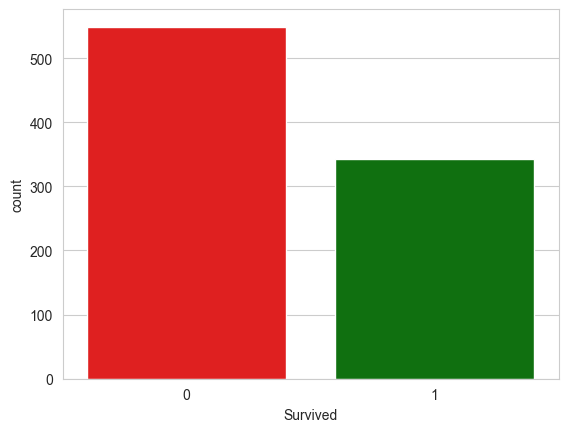

In [6]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Survived', data=df, palette=['red', 'green'], legend=False)

0: Represents passengers who did not survive (died).

1: Represents passengers who survived.

<Axes: xlabel='Survived', ylabel='count'>

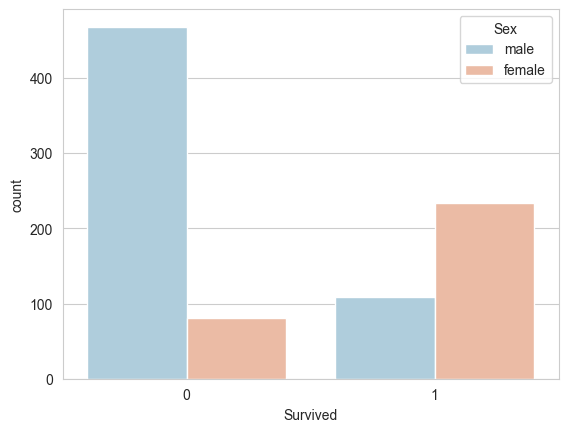

In [7]:
sns.set_style("whitegrid")
sns.countplot(x="Survived", hue="Sex", data=df, palette="RdBu_r")

<Axes: xlabel='Survived', ylabel='count'>

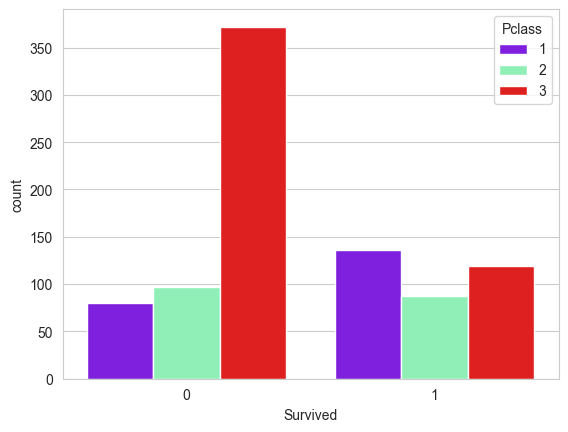

In [10]:
sns.set_style("whitegrid")
sns.countplot(x="Survived", hue="Pclass", data=df, palette="rainbow")

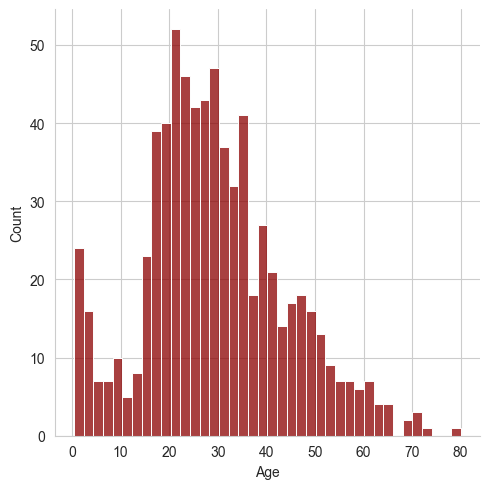

In [8]:
sns.displot(df['Age'].dropna(), kde=False, bins=40, color="darkred")

<Axes: >

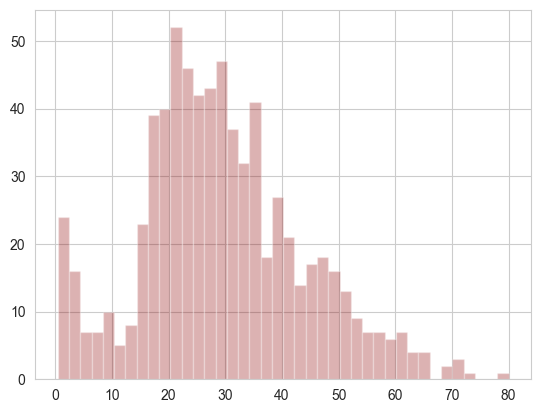

In [9]:
df["Age"].hist(color="darkred", bins=40, alpha=0.3)

The alpha parameter controls the transparency (opacity) of the bars.   

- Setting alpha=0.3 makes the bars semi-transparent so that the background grid lines (whitegrid) can still be seen clearly through the graph

1. alpha=1.0 (default): The bars are fully solid and opaque.   
2. alpha=0.3: The bars become transparent (see-through).  

<Axes: xlabel='SibSp', ylabel='count'>

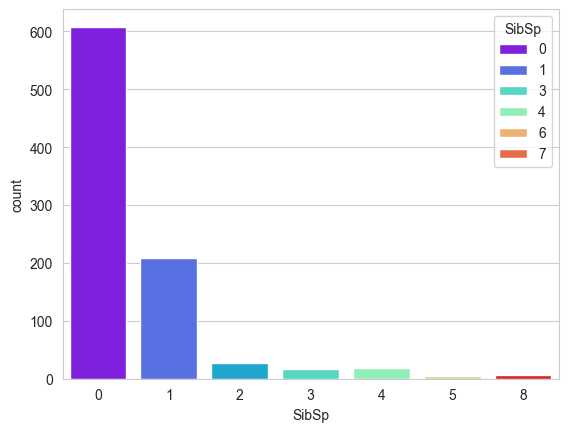

In [12]:
sns.countplot(x="SibSp", hue="SibSp", data=df, palette="rainbow")

<Axes: >

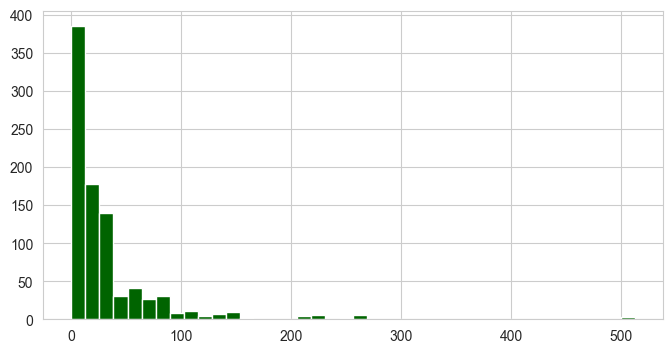

In [14]:
df["Fare"].hist(color="darkgreen", bins=40, figsize=(8,4))

### Cufflinks for plots

Because it uses Plotly under the hood, when you run this in your notebook, you will be able to hover your mouse over any bar to see the exact count and fare range instantly!

In [17]:
import cufflinks as cf
cf.go_offline()

-------------------------------------------------------------------------------------------------------------------------------------

#### DATA CLEANING


In short, we use boxplots for data cleaning for two main reasons:

* **Conditional Imputation:** It shows relationships between variables (like Age and Pclass) so you can fill in missing values using category-specific averages rather than an inaccurate global average[cite: 1].
* **Outlier Detection:** It clearly highlights extreme anomalies (shown as individual points beyond the whiskers) so you can decide whether to remove or correct them[cite: 1].

In [ ]:
plt.figure(figsize=(12,7))
sns.boxplot(x='Pclass', y='Age', data=df, )